# Module 5 — Calibration: Can You Trust the Probabilities?

## Why you're here: what the model is for
- A risk score is used as a **probability**: "this client has a 30% chance of
  defaulting" feeds decisions like estimating expected losses, or setting limits
  and prices. So a score of 0.3 has to really mean 30%.
- Module 4, Part 7 showed that ranking well isn't enough: the balanced forest
  ranked clients almost as well as the plain forest, yet clients it scored about
  0.4 really defaulted only 18.1% of the time.
- **Calibration** means checking that scores mean what they say, and correcting
  them when they don't. The correction has to be learned on rows the model
  didn't train on, and this module shows why, which is the reason the validation
  rows exist (as promised in Module 2).
- The column is still `default` (the bank's label, never defined in the source
  data).

**Your endgame in this module:** judge whether a model's scores can be read as
probabilities, correct them if not, and see why the correction needs its own rows.

## From the curriculum

> ### <u>Module 5 — Calibration: Can You Trust the Probabilities?</u>
>
> **Concepts**
> - Ranking (does the model give riskier clients higher scores?) vs. calibration (when it
>   says 30%, do about 30% default?). They are different properties
> - Reliability diagrams and the Brier score
> - Why anything trained with `class_weight` comes out miscalibrated (forests can
>   be too, though Module 3's plain forest turns out well calibrated on this data)
> - Two ways to correct scores, sigmoid vs. isotonic (scikit-learn packages them as
>   `CalibratedClassifierCV`), and why the correction must be learned on rows the
>   model was not trained on
>
> **Why it matters**
> A risk score is used as a probability: for expected-loss arithmetic, pricing,
> and "flag everyone above 20%". If the probabilities are off, every decision
> built on them is off, even when the ranking is excellent.
>
> **Worked example**
> Reliability diagrams for logistic regression, Module 3's plain forest and Module 4's
> balanced forest on the validation rows, then the balanced forest corrected, with
> the Brier score for each. Plus a test of the rule itself: the same correction
> learned on training rows vs. validation rows, for a forest that memorises and for
> one that doesn't.
>
> **Resources**
> - [Probability calibration](https://scikit-learn.org/stable/modules/calibration.html)
>   (scikit-learn user guide §1.16, ~20 min, verified).
>
> **Exercise type:** read-the-reliability-diagram drills: over/under
> confident, where, and what it would cost.
>
> **Interview angle:** "Your model says 30% risk. What does that mean, and how
> would you check it?"

## Lesson

### Two different properties
- **Ranking:** does the model put riskier clients higher? That's what ROC-AUC
  measures (Modules 1–4).
- **Calibration:** when the model says P, does a share P of those clients really
  default? A model can rank perfectly and still say 0.8 where the truth is 0.4:
  the order is right, the numbers are wrong.

### The check: group, then compare
1. Sort the clients by score and cut them into **10 equal-sized groups**: the
   lowest-scored tenth, the next tenth, and so on. Ten groups of 600 validation
   clients each is a common choice: enough groups to see a shape, enough clients
   per group for a stable share.
2. For each group, compare two numbers: the group's **average score** (what the
   model says) and its **real share of defaulters** (what happened).
3. Honest scores give matching pairs. On a chart with average score on X and
   real share on Y, honest groups sit on the **diagonal**. This chart is called a
   **reliability diagram**.

### One number for honesty: the Brier score
The **Brier score** is the average, over all clients, of (score − outcome)²,
where the outcome is 1 for a defaulter and 0 for a payer. It's 0 for perfect
scores, and lower is better. It improves when defaulters get high scores and payers
low ones (good ranking), and when scores match the real shares (honesty).

A baseline to compare against: a "model" that gives every client the same score,
the real share of defaulters, call it R. Its Brier score works out to R × (1 − R).
For defaulters, (R − 1)² = (1 − R)², and they are a share R of clients; for
payers, (R − 0)² = R², a share (1 − R). So the average is
R × (1 − R)² + (1 − R) × R² = R × (1 − R) × [(1 − R) + R] = R × (1 − R).

### The correction: a translation from score to probability
If a model's scores are off, learn a **translation**: a rule that takes a score
and returns an honest probability. It's learned from rows where both the score
and the real outcome are known. Two common shapes:
- **Sigmoid:** a smooth S-shaped curve, fitted as a small logistic regression on
  the score alone (its two numbers are an intercept and a slope). Robust with few
  rows, but it can only fix mistakes that follow that S shape.
- **Isotonic:** a staircase that can take any shape, as long as it never goes
  down (a higher score never becomes a lower probability). More flexible, so it
  needs more rows to learn from.

The translation never swaps two clients' order, so the ranking is kept. (Isotonic
can merge a few close scores into ties, so ROC-AUC may move very slightly.) What
changes is the numbers.

### The rule
The translation must be learned on rows the model **did not train on**. Part 3
shows what goes wrong otherwise, and why that means the validation rows.

### Still not a cause
Calibration makes scores honest; it says nothing about why clients default.

### Part 0 — The three models and their scores
All three are trained on the same 18,000 training rows and scored on the 6,000
validation rows:
- **logistic regression** on the 15 prepared columns (as in Module 3, Part 3);
- **the plain forest** from Module 3 (300 trees, each tree's final groups holding at
  least 50 clients);
- **the balanced forest** from Module 4 (the same, with `class_weight="balanced"`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss, roc_auc_score

from common import load_credit, credit_split, prepare_credit

BLUE, ORANGE, MAGENTA = "#2a78d6", "#eb6834", "#e87ba4"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110})

train, valid, test = credit_split(load_credit())
X_train, y_train = prepare_credit(train), train["default"].to_numpy()
X_valid, y_valid = prepare_credit(valid), valid["default"].to_numpy()

logit = sm.Logit(y_train, sm.add_constant(X_train)).fit(disp=0)
forest = RandomForestClassifier(n_estimators=300, min_samples_leaf=50, n_jobs=-1, random_state=0).fit(X_train, y_train)
balanced = RandomForestClassifier(n_estimators=300, min_samples_leaf=50, n_jobs=-1, random_state=0,
                                  class_weight="balanced").fit(X_train, y_train)

scores = {"logistic regression": logit.predict(sm.add_constant(X_valid)).to_numpy(),
          "plain forest": forest.predict_proba(X_valid)[:, 1],
          "balanced forest": balanced.predict_proba(X_valid)[:, 1]}
colors = {"logistic regression": ORANGE, "plain forest": BLUE, "balanced forest": MAGENTA}

share = y_valid.mean()
print(f"training rows: {len(y_train):,}; validation rows: {len(y_valid):,}; real share of defaulters in validation R = {share:.3f}")
print(f"Brier score of giving everyone the same score R: R x (1 - R) = {share:.3f} x {1 - share:.3f} = {share * (1 - share):.4f}\n")
print(f"{'':<22}{'ROC-AUC':>9}{'average score':>15}{'Brier score':>13}")
for name, s in scores.items():
    print(f"{name:<22}{roc_auc_score(y_valid, s):>9.4f}{s.mean():>15.3f}{brier_score_loss(y_valid, s):>13.4f}")

training rows: 18,000; validation rows: 6,000; real share of defaulters in validation R = 0.221
Brier score of giving everyone the same score R: R x (1 - R) = 0.221 x 0.779 = 0.1723

                        ROC-AUC  average score  Brier score
logistic regression      0.7575          0.222       0.1390
plain forest             0.7830          0.221       0.1348
balanced forest          0.7819          0.430       0.1803


**Observation:** all three rank clients about equally well (ROC-AUC 0.76 to 0.78).
The plain forest and logistic regression have average scores matching the real
share of defaulters (0.221), and the lowest Brier scores. The balanced forest's
average score is about twice the real share, and its Brier score is **worse than
giving every client the same score** (0.1803 against 0.1723). Its ranking is good;
its numbers are not.

### Part 1 — The check, group by group
Each row is one group of 600 validation clients, sorted by score (group 1 = the
lowest-scored tenth). For each model, two numbers: the group's **average score**
(what the model says) and its **real share of defaulters** (what happened). Honest
scores make the two match.

In [2]:
def groups(s, y, n_groups=10):
    g = pd.qcut(pd.Series(s).rank(method="first"), n_groups, labels=False)   # ties broken by row order, so groups stay equal-sized
    return pd.DataFrame({"score": s, "y": y, "g": g}).groupby("g").agg(
        average_score=("score", "mean"), real_share=("y", "mean"))

tables = {name: groups(s, y_valid) for name, s in scores.items()}
wide = pd.concat({name: t for name, t in tables.items()}, axis=1).round(3)
wide.index = [f"{i + 1}" for i in wide.index]
wide.index.name = "group (1 = lowest scores)"
print(wide.to_string())

                          logistic regression             plain forest            balanced forest           
                                average_score real_share average_score real_share   average_score real_share
group (1 = lowest scores)                                                                                   
1                                       0.073      0.078         0.068      0.053           0.190      0.053
2                                       0.110      0.100         0.089      0.058           0.243      0.063
3                                       0.125      0.105         0.107      0.083           0.285      0.082
4                                       0.136      0.092         0.124      0.110           0.320      0.100
5                                       0.147      0.132         0.142      0.143           0.354      0.150
6                                       0.160      0.160         0.166      0.153           0.395      0.157
7                  

For each group and model: the **gap** between the two numbers above
(|average score − real share|), the group's **margin of error** (2 × √(real
share × (1 − real share) ÷ 600), the usual 95% margin for a share, as in A/B
testing, from each group's own real share), and **within**: "yes" when the gap
is no bigger than the margin, i.e. the mismatch could be chance.

In [3]:
checks = {}
for name, t in tables.items():
    gap = (t["average_score"] - t["real_share"]).abs()
    margin = 2 * np.sqrt(t["real_share"] * (1 - t["real_share"]) / 600)
    checks[name] = pd.DataFrame({"gap": gap.round(3), "margin": margin.round(3),
                                 "within": np.where(gap <= margin, "yes", "NO")})
check_table = pd.concat(checks, axis=1)
check_table.index = [f"{i + 1}" for i in check_table.index]
check_table.index.name = "group"
print(check_table.to_string())
print()
for name, c in checks.items():
    print(f"{name}: {(c['within'] == 'yes').sum()} of 10 groups within their margin")

      logistic regression               plain forest               balanced forest              
                      gap margin within          gap margin within             gap margin within
group                                                                                           
1                   0.005  0.022    yes        0.014  0.018    yes           0.136  0.018     NO
2                   0.010  0.024    yes        0.031  0.019     NO           0.179  0.020     NO
3                   0.020  0.025    yes        0.024  0.023     NO           0.204  0.022     NO
4                   0.045  0.024     NO        0.014  0.026    yes           0.220  0.024     NO
5                   0.015  0.028    yes        0.001  0.029    yes           0.204  0.029     NO
6                   0.000  0.030    yes        0.012  0.029    yes           0.238  0.030     NO
7                   0.011  0.032    yes        0.034  0.034    yes           0.223  0.034     NO
8                   0.047  0.0

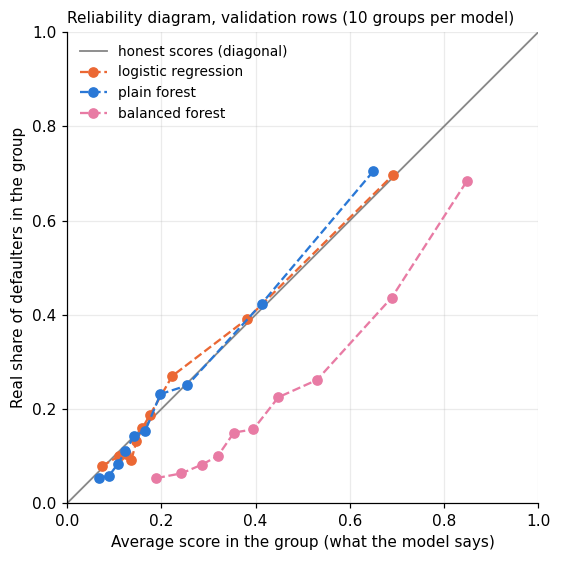

In [4]:
fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.plot([0, 1], [0, 1], color="#888888", linewidth=1.2, label="honest scores (diagonal)")
for name, t in tables.items():
    ax.plot(t["average_score"], t["real_share"], marker="o", markersize=6, linewidth=1.5, linestyle="--",
            color=colors[name], label=name)
ax.set_xlabel("Average score in the group (what the model says)")
ax.set_ylabel("Real share of defaulters in the group")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
ax.legend(frameon=False, loc="upper left", fontsize=9)
ax.set_title("Reliability diagram, validation rows (10 groups per model)", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

*Reading the chart: each dot is one group of 600 clients. The dashed lines only
connect a model's groups in order.*

**Observation:** logistic regression has 8 of its 10 groups within their margin of
error, and the plain forest 7 of 10; both sit close to the diagonal. Their other
groups miss by small amounts, the largest being the plain forest's group 10 (0.650
against 0.705). The balanced forest has none of its 10 groups within the margin:
they all sit **below** the diagonal. In every group,
fewer clients defaulted than its scores claimed. Its lowest group averages a score
of 0.190 while only 5.3% of those clients defaulted.

**Conclusion:** the plain forest's and logistic regression's scores are close
enough to be read as probabilities for most uses. The balanced forest can't, and needs correcting.

### Part 2 — Correcting the scores
The translation has to be learned on rows where the outcome is known, and then
checked on **other** rows, because a correction checked on the rows it learned
from would look better than it is (the same reason models are graded on rows they
didn't learn from). So the 6,000 validation rows are split into two equal halves,
so that both learning and checking get enough rows, keeping the same share of
defaulters in each:
- **half A (3,000 rows):** the translation is learned here;
- **half B (3,000 rows):** it's checked here.

In [5]:
idx_a, idx_b = train_test_split(np.arange(len(y_valid)), test_size=0.5, stratify=y_valid, random_state=0)
print(f"half A: {len(idx_a):,} rows, {y_valid[idx_a].mean():.3f} defaulters; half B: {len(idx_b):,} rows, {y_valid[idx_b].mean():.3f} defaulters\n")

def sigmoid_fit(s, y):
    m = LogisticRegression().fit(s.reshape(-1, 1), y)
    return lambda new: m.predict_proba(new.reshape(-1, 1))[:, 1]

def isotonic_fit(s, y):
    m = IsotonicRegression(out_of_bounds="clip").fit(s, y)   # scores outside the range seen when learning get the nearest learned value
    return m.predict

rows = []
for name, s in scores.items():
    sig = sigmoid_fit(s[idx_a], y_valid[idx_a])
    iso = isotonic_fit(s[idx_a], y_valid[idx_a])
    rows.append({"model": name,
                 "Brier: as is": brier_score_loss(y_valid[idx_b], s[idx_b]),
                 "Brier: sigmoid": brier_score_loss(y_valid[idx_b], sig(s[idx_b])),
                 "Brier: isotonic": brier_score_loss(y_valid[idx_b], iso(s[idx_b])),
                 "avg score: as is": s[idx_b].mean(),
                 "avg score: sigmoid": sig(s[idx_b]).mean(),
                 "avg score: isotonic": iso(s[idx_b]).mean(),
                 "ROC-AUC: as is": roc_auc_score(y_valid[idx_b], s[idx_b]),
                 "ROC-AUC: sigmoid": roc_auc_score(y_valid[idx_b], sig(s[idx_b])),
                 "ROC-AUC: isotonic": roc_auc_score(y_valid[idx_b], iso(s[idx_b]))})
    if name == "balanced forest":
        corrected_sig, corrected_iso = sig(s[idx_b]), iso(s[idx_b])
print("All measured on half B (real share of defaulters there:", f"{y_valid[idx_b].mean():.3f}):")
part2 = pd.DataFrame(rows).round(4)
w = part2["model"].str.len().max()
print(part2.to_string(index=False, formatters={"model": lambda s: s.ljust(w)}, justify="left"))

half A: 3,000 rows, 0.221 defaulters; half B: 3,000 rows, 0.221 defaulters

All measured on half B (real share of defaulters there: 0.221):
model                Brier: as is  Brier: sigmoid  Brier: isotonic  avg score: as is  avg score: sigmoid  avg score: isotonic  ROC-AUC: as is  ROC-AUC: sigmoid  ROC-AUC: isotonic
logistic regression 0.1427        0.1428          0.1430           0.2254            0.2275              0.2275               0.7538          0.7538            0.7471            
plain forest        0.1369        0.1379          0.1385           0.2229            0.2263              0.2266               0.7757          0.7757            0.7717            
balanced forest     0.1829        0.1376          0.1386           0.4312            0.2244              0.2255               0.7745          0.7745            0.7736            


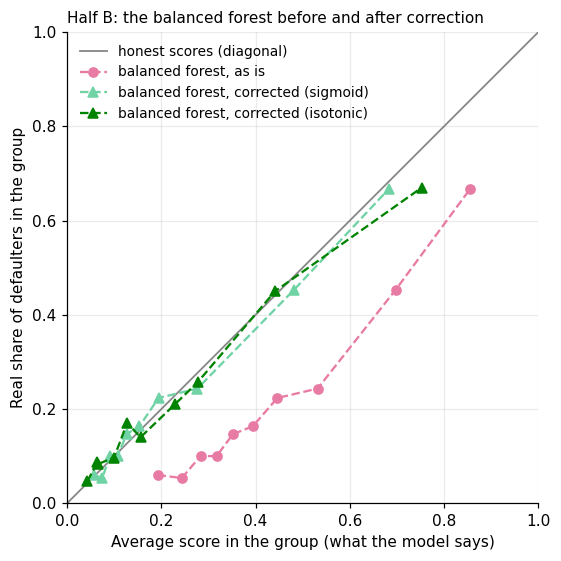

In [6]:
before = groups(scores["balanced forest"][idx_b], y_valid[idx_b])
after_sig = groups(corrected_sig, y_valid[idx_b])
after_iso = groups(corrected_iso, y_valid[idx_b])
fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.plot([0, 1], [0, 1], color="#888888", linewidth=1.2, label="honest scores (diagonal)")
ax.plot(before["average_score"], before["real_share"], marker="o", markersize=6, linewidth=1.5, linestyle="--",
        color=MAGENTA, label="balanced forest, as is")
ax.plot(after_sig["average_score"], after_sig["real_share"], marker="^", markersize=7, linewidth=1.5, linestyle="--",
        color="#6fd3a5", label="balanced forest, corrected (sigmoid)")
ax.plot(after_iso["average_score"], after_iso["real_share"], marker="^", markersize=7, linewidth=1.5, linestyle="--",
        color="#008300", label="balanced forest, corrected (isotonic)")
ax.set_xlabel("Average score in the group (what the model says)")
ax.set_ylabel("Real share of defaulters in the group")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
ax.legend(frameon=False, loc="upper left", fontsize=9)
ax.set_title("Half B: the balanced forest before and after correction", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

*Reading the chart: each dot is one group of 300 half-B clients; the dashed lines
only connect a model's groups in order.*

**Observation:** on half B, the correction brings the balanced forest's groups
onto the diagonal, and its Brier score down to the level of the plain forest's.
Sigmoid and isotonic end up close (0.1376 against 0.1386), too close to call; the
chart shows both. For the plain forest and
logistic regression, the correction doesn't help, and even makes them very
slightly worse, by differences too small to call.

**Hypothesis:** the plain forest's and logistic regression's scores were already
honest, so a translation learned from only 3,000 rows adds a little noise of its
own. ROC-AUC (last three columns) is unchanged by sigmoid; isotonic lowers it slightly,
because its staircase turns some slightly different scores into the same value: by
0.0009 for the balanced forest, 0.0040 for the plain forest and 0.0067 for logistic
regression. The ranking survives, with sigmoid keeping it exactly.

**Conclusion:** a model with good ranking but dishonest numbers can be repaired
without retraining it. Only the balanced forest needed repairing here.

### Part 3 — The rule: why the correction needs rows the model didn't train on
The question: could the translation simply be learned on the **training rows**?
There, too, both the scores and the outcomes are known.

The test: learn the same isotonic translation twice (isotonic, the more flexible
of the two, copies over-confident scores most faithfully), once on the training
rows and once on validation half A, and check both on half B. Done for two forests:
- a forest that **memorises** (each tree's final groups may hold a single client,
  the over-fitted forest from Module 3, Part 2);
- **Module 3's plain forest** (final groups of at least 50 clients).

In [7]:
memoriser = RandomForestClassifier(n_estimators=300, min_samples_leaf=1, n_jobs=-1, random_state=0).fit(X_train, y_train)
rows = []
for name, model in [("memorising forest", memoriser), ("Module 3's plain forest", forest)]:
    s_train, s_valid = model.predict_proba(X_train)[:, 1], model.predict_proba(X_valid)[:, 1]
    on_train = isotonic_fit(s_train, y_train)(s_valid[idx_b])
    on_valid = isotonic_fit(s_valid[idx_a], y_valid[idx_a])(s_valid[idx_b])
    rows.append({"forest": name,
                 "avg score: training defaulters": s_train[y_train == 1].mean(),
                 "avg score: validation defaulters": s_valid[y_valid == 1].mean(),
                 "Brier on B: learned on training rows": brier_score_loss(y_valid[idx_b], on_train),
                 "Brier on B: learned on half A": brier_score_loss(y_valid[idx_b], on_valid)})
part3 = pd.DataFrame(rows).round(4)
w = part3["forest"].str.len().max()
print(part3.to_string(index=False, formatters={"forest": lambda s: s.ljust(w)}, justify="left"))
print(f"\n(Brier of giving everyone the same score on half B: {y_valid[idx_b].mean() * (1 - y_valid[idx_b].mean()):.4f})")

forest                   avg score: training defaulters  avg score: validation defaulters  Brier on B: learned on training rows  Brier on B: learned on half A
memorising forest       0.7790                          0.4006                            0.1790                                0.1439                        
Module 3's plain forest 0.3828                          0.3749                            0.1377                                0.1385                        

(Brier of giving everyone the same score on half B: 0.1722)


**Observation:** the memorising forest scores its own training defaulters far
higher than it scores validation defaulters, because it has memorised them. A
translation learned from those over-confident training scores is wrong for new
clients: its Brier score on half B is worse than giving everyone the same score
(0.1790 against 0.1722). Learned on half A, the translation works. For Module 3's plain forest, which
barely memorises, the two versions come out about the same.

**Conclusion: the rule, and the reason for the validation rows.**
- A model's scores on its own training rows can be over-confident. How much, you'd
  have to measure for every model, and it can only be measured on rows the model
  didn't train on. So the translation must be learned on rows the model didn't
  train on, **always**, even though for some models (like Module 3's plain forest) the
  difference turns out small (for the plain forest, the training rows even came
  out marginally ahead).
- Those rows can't be the **test** rows: the final grade on the test rows
  (Module 6) must come from rows nothing was learned from.
- The simplest option is the **validation rows**. This is the second reason they
  were set aside in Module 2 (the first: comparing models, Modules 3–4).
- The other option: scikit-learn's `CalibratedClassifierCV` cuts the training rows
  into parts, trains the model on all but one, learns the translation on the one
  left out, and rotates, like Module 1's cross-validation. It obeys the same rule
  without separate rows.

## Exercises

For each claim below: say what's wrong with it, then rewrite it correctly. The
answer follows each claim.

**(a) "The plain forest and the balanced forest have almost the same ROC-AUC, so
their scores are equally trustworthy as probabilities."**
ROC-AUC measures ranking, not honesty. **Rewrite (Observation):** "Both rank clients
about equally well (ROC-AUC 0.7830 and 0.7819, Part 0), but only the plain forest's
scores can be read as probabilities: its Brier score is 0.1348 against the balanced
forest's 0.1803, and 7 of its 10 groups are within their margin of error, against
none of the balanced forest's (Part 1)."

**(b) "We learned the correction on half A and it cut the Brier score on half A,
so it works."** (A hypothetical claim: the notebook never checks this way.)
Checked on the rows it learned from, a correction looks better than it really is. **Rewrite
(Observation):** "Learned on half A and checked on half B, the correction brought
the balanced forest's Brier score down to the plain forest's level."

**(c) "To be safe, we learned the correction on the test rows."**
Then Module 6's final grade would come from rows the model's scores were adjusted
on. **Rewrite (Conclusion):** "The correction is learned on half A of the
validation rows; the test rows stay untouched until the final grade."

**(d) "The correction learned on training rows worked fine for Module 3's plain forest,
so training rows are good enough."**
It worked for that forest because it barely memorises; for a forest that does,
it failed (Part 3). **Rewrite (Conclusion):** "Learn the correction on rows the
model didn't train on, since how much a model memorises isn't known in advance."

## Key takeaways

- **Conclusion:** ranking and calibration are different. The balanced forest
  ranks almost as well as the plain forest, but its Brier score is not only worse
  than the plain forest's (0.1803 against 0.1348), but even worse than giving
  every client the same score (0.1723).
- **Conclusion:** a reliability diagram (10 groups, average score against real
  share) shows where scores are too high or too low. Honest groups sit on the
  diagonal.
- **Conclusion:** a translation learned from scores to outcomes (sigmoid or
  isotonic) repairs dishonest scores without retraining and keeps the ranking.
  On this data, only the balanced forest needed it.
- **Conclusion:** the translation must be learned on rows the model didn't train
  on. For a memorising forest, learning it on training rows made it useless; the
  validation rows exist for exactly this.
- **Conclusion:** calibration makes scores honest; it says nothing about why
  clients default.